<a href="https://colab.research.google.com/github/krishnasaijoga/ScalerCaseStudies/blob/main/CO2CS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn import metrics
import numpy as np

In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv
To: /content/CO2_Emissions.csv
100% 476k/476k [00:00<00:00, 519kB/s]


In [ ]:
co2 = pd.read_csv('CO2_Emissions.csv')

# Q1
Begin by familiarizing yourself with the dataset. Identify what kind of information
is captured about vehicles and how these variables might influence CO₂
emissions

In [ ]:
co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
# Table representing Features, type, description and influence on Target variable
feature_desc = pd.DataFrame(columns=['Feature', 'FType', 'Description', 'Influence on CO2 emissions'])
feature_desc['Feature'] = ['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']
feature_desc['FType'] = ['Categorical', 'Categorical', 'Categorical', 'Numerical', 'Numerical', 'Categorical', 'Categorical', 'Numerical', 'Numerical', 'Numerical', 'Numerical', 'Numerical']
feature_desc['Description'] = ['Manufacturer of the vehicle. unique values: 42. Eg: ACURA, ALFA ROMEO, ASTON MARTIN',
                               'Specific car model. unique values: 2053. Eg: Tacoma 4WD D-Cab TRD Off-Road/Pro,Atlas Cross Sport 4MOTION, XC40 T4 AWD Here 4WD indicates Four-wheel drive',
                               'Specific vehicle class. Eg: COMPACT,SUV - SMALL,MID-SIZE',
                               'Engine Capacity in litres',
                               'Number of engine cylinders: [ 3  4  5  6  8 10 12 16]. Eg: 3 means 3 cylinder engine',
                               'Dentoes what type of transmission type along with number of gears. Eg: AS5 denotes Automatic Select Shift with 5 gears',
                               'Denotes fuel used by the engine',
                               'Fuel consumption in L/100Km in city traffic',
                               'Fuel consumption in L/100Km in Highway traffic',
                               'Weighted combination of 55% of Fuel consumption in L/100Km City and 45% of Fuel consumption in L/100Km Hwy',
                               'Fuel consumption Comb in a different units Miles Per Gallon (mpg). 1 mpg = 282.415 l/100km',
                               'Amount of CO2 emitted in grams per Kilometer of Combined city and highway']
feature_desc['Influence on CO2 emissions'] = [
    'Different companies use different technologies and designs. Some prioritize efficiency, while others focus on performance — influencing emissions indirectly.',
    'Models vary in engine size, weight, and aerodynamics — all affecting emissions',
    'Larger/heavier vehicles generally consume more fuel and emit more CO₂',
    'Higher Capacity engines burn more fuel per kilometer → higher CO₂ emissions.',
    'More cylinders often mean more fuel consumption and emissions (though newer tech may optimize this).',
    'Transmission efficiency affects fuel usage; more gears or CVT can reduce CO₂ emissions',
    'Different fuels emit different amounts of CO₂ — Diesel typically emits more CO₂ per liter, while hybrids/electrics emit less or non',
    'Higher the number higher the emissions',
    'Higher the number higher the emissions',
    'Higher the number higher the emissions',
    'Lower the number higher the emissions',
    'Target Variable'
]
feature_desc


,Feature,FType,Description,Influence on CO2 emissions
0,Make,Categorical,Manufacturer of the vehicle. unique values: 42...,Different companies use different technologies...
1,Model,Categorical,Specific car model. unique values: 2053. Eg: T...,"Models vary in engine size, weight, and aerody..."
2,Vehicle Class,Categorical,"Specific vehicle class. Eg: COMPACT,SUV - SMAL...",Larger/heavier vehicles generally consume more...
3,Engine Size(L),Numerical,Engine Capacity in litres,Higher Capacity engines burn more fuel per kil...
4,Cylinders,Numerical,Number of engine cylinders: [ 3 4 5 6 8 10...,More cylinders often mean more fuel consumptio...
5,Transmission,Categorical,Dentoes what type of transmission type along w...,Transmission efficiency affects fuel usage; mo...
6,Fuel Type,Categorical,Denotes fuel used by the engine,Different fuels emit different amounts of CO₂ ...
7,Fuel Consumption City (L/100 km),Numerical,Fuel consumption in L/100Km in city traffic,Higher the number higher the emissions
8,Fuel Consumption Hwy (L/100 km),Numerical,Fuel consumption in L/100Km in Highway traffic,Higher the number higher the emissions
9,Fuel Consumption Comb (L/100 km),Numerical,Weighted combination of 55% of Fuel consumptio...,Higher the number higher the emissions


Data contains a column called CO2 emissions(g/Km) that denotes how much emissions for each vehicle with make, model, vehicle class, engine size(L), # of cylinders, transmission mode, fuel type, fuel consumption (L/100 Km) in city Hwy, Comb, and fuel consumption(mpg) comb.
These features may inflence co2 emissions.
All numerical columns should not have negative or missing values.

We aim to find major contributors to CO2 emissions and predict a model that identifies vehicles which result in lesser emissions.

# Q2
Examine the dataset for any inconsistencies, missing entries, or data quality
issues. Consider what preprocessing steps may be necessary to make the
dataset ready for meaningful analysis

In [ ]:
co2.isna().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


In [ ]:
co2['Make'] = co2['Make'].str.upper()
co2['Model'] = co2['Model'].str.upper()
co2['Vehicle Class'] = co2['Vehicle Class'].str.upper()
co2['Transmission'] = co2['Transmission'].str.upper()
co2['Fuel Type'] = co2['Fuel Type'].str.upper()
# Identify duplicate rows
print("Number of duplicate rows:", co2.duplicated().sum())

# Remove duplicate rows
print("Shape of DataFrame after removing duplicates:", co2.drop_duplicates().shape)
co2 = co2.drop_duplicates()

Number of duplicate rows: 1394
Shape of DataFrame after removing duplicates: (5991, 12)


In [ ]:
co2['Model'].unique()

array(['ILX', 'ILX HYBRID', 'MDX 4WD', ...,
       'TACOMA 4WD D-CAB TRD OFF-ROAD/PRO', 'ATLAS CROSS SPORT 4MOTION',
       'XC40 T4 AWD'], dtype=object)

In [ ]:
# Data consistency check in categorical columns
categorical_cols = co2.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(co2[col].unique())
    print(f"\nValue counts for '{col}':")
    print(co2[col].value_counts())
    print("-" * 30)

Unique values in 'Make':
['ACURA' 'ALFA ROMEO' 'ASTON MARTIN' 'AUDI' 'BENTLEY' 'BMW' 'BUICK'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER' 'DODGE' 'FIAT' 'FORD' 'GMC' 'HONDA'
 'HYUNDAI' 'INFINITI' 'JAGUAR' 'JEEP' 'KIA' 'LAMBORGHINI' 'LAND ROVER'
 'LEXUS' 'LINCOLN' 'MASERATI' 'MAZDA' 'MERCEDES-BENZ' 'MINI' 'MITSUBISHI'
 'NISSAN' 'PORSCHE' 'RAM' 'ROLLS-ROYCE' 'SCION' 'SMART' 'SRT' 'SUBARU'
 'TOYOTA' 'VOLKSWAGEN' 'VOLVO' 'GENESIS' 'BUGATTI']

Value counts for 'Make':
Make
FORD             563
CHEVROLET        503
BMW              492
MERCEDES-BENZ    363
GMC              278
AUDI             263
PORSCHE          257
TOYOTA           252
NISSAN           192
JEEP             188
MINI             187
KIA              182
VOLKSWAGEN       180
HYUNDAI          172
DODGE            151
HONDA            144
CADILLAC         141
LEXUS            129
MAZDA            125
VOLVO            118
SUBARU           112
JAGUAR           102
BUICK             91
INFINITI          86
LINCOLN           78
LAND ROVER  

There are no inconsistencies in categorical columns

In [ ]:
co2.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),CO2 Emissions(g/km),gears,Fuel Consumption City (L/100 km) log,Fuel Consumption Hwy (L/100 km) log
count,5991.000000,5991.000000,5991.000000,5991.000000,5991.000000,5991.000000,5991.000000,5991.000000
mean,3.173043,5.633784,12.650075,9.091320,251.638124,6.609247,2.499281,2.178028
std,1.365751,1.851161,3.560977,2.293336,59.246929,1.765664,0.278052,0.238903
min,0.900000,3.000000,4.200000,4.000000,96.000000,0.000000,1.435085,1.386294
25%,2.000000,4.000000,10.100000,7.500000,208.000000,6.000000,2.312535,2.014903
50%,3.000000,6.000000,12.100000,8.700000,246.000000,6.000000,2.493205,2.163323
75%,3.800000,6.000000,14.700000,10.300000,290.000000,8.000000,2.687847,2.332144
max,8.400000,16.000000,30.600000,20.600000,522.000000,10.000000,3.421000,3.025291


Since count of each column is 6282, which is equal to de duplicated size of data frame , we infer that there are no inconsistencies in numerical columns.
Also, the min values are positive for every column, there are no negative values in data.

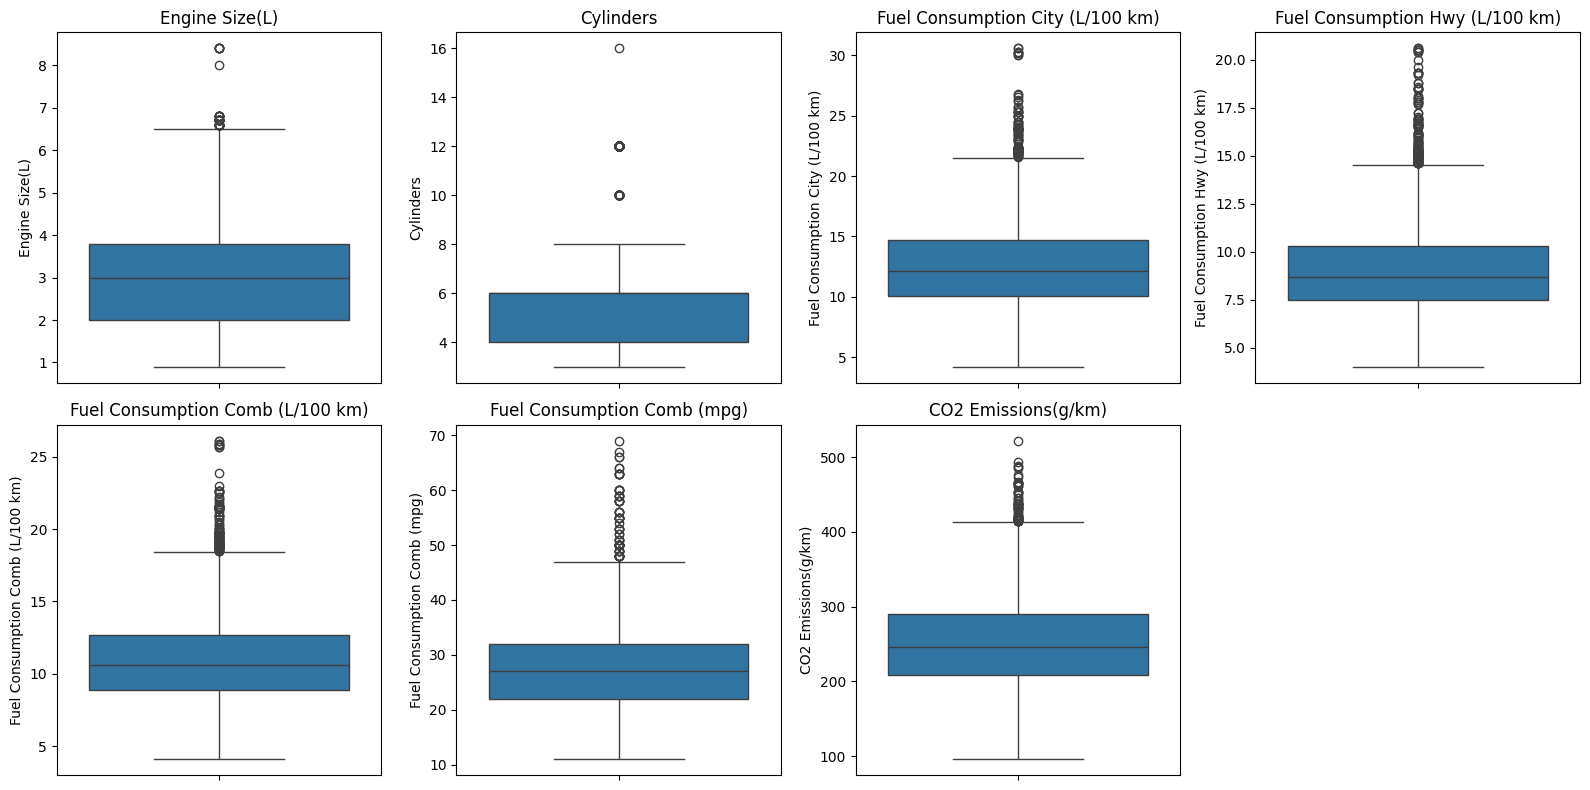

In [ ]:
#Univariate Outlier analysis
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select the numerical columns to plot
numerical_cols_to_plot = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
                          'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
                          'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']

# Determine the number of rows and columns for the subplots
n_cols = 4
n_rows = (len(numerical_cols_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten() # Flatten the axes array for easy iteration

# Loop through the numerical columns and create a boxplot for each
for i, col in enumerate(numerical_cols_to_plot):
    sns.boxplot(data=co2[col], ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

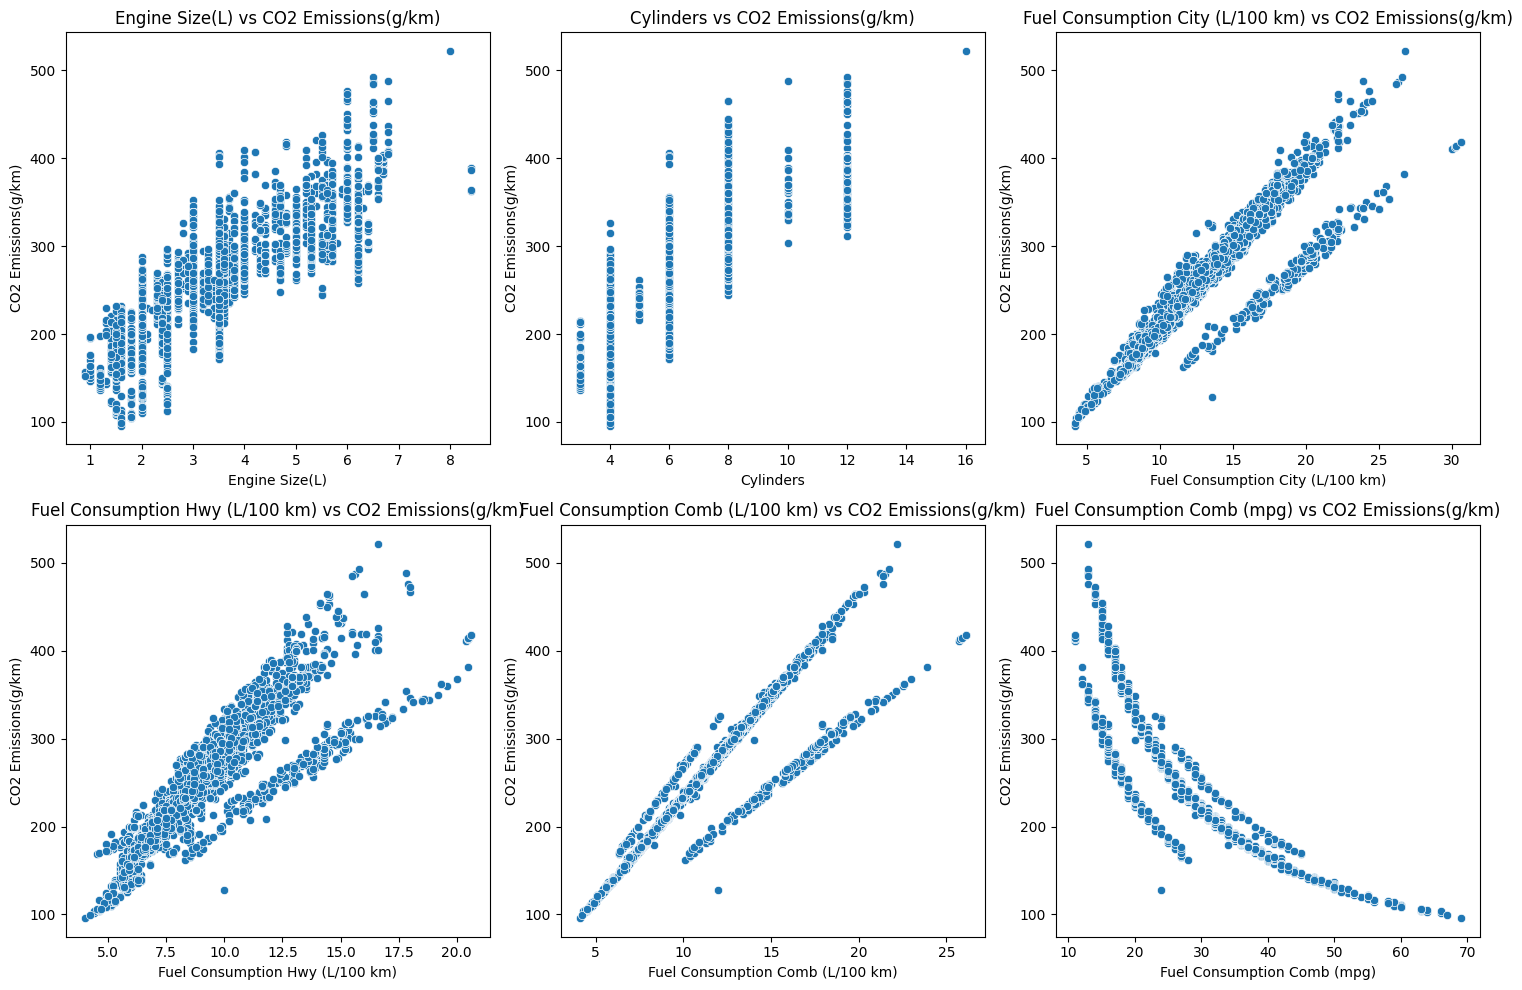

In [ ]:
# Outlier analysis between features and target variable
numerical_cols = co2.select_dtypes(include=np.number).columns.tolist()
numerical_features = [col for col in numerical_cols if col != 'CO2 Emissions(g/km)']

# Determine the number of rows and columns for the subplots
n_cols = 3
n_rows = (len(numerical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the axes array for easy iteration

# Loop through the numerical features and create a scatter plot against CO2 Emissions
for i, col in enumerate(numerical_features):
    sns.scatterplot(data=co2, x=col, y='CO2 Emissions(g/km)', ax=axes[i])
    axes[i].set_title(f'{col} vs CO2 Emissions(g/km)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('CO2 Emissions(g/km)')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

There are outliers in data, but they are geniuene extremes in data.
Eg: Number of cylinders can be 16 for some vehicles

In [ ]:
co2_test = co2[['Fuel Consumption Comb (L/100 km)','Fuel Consumption Comb (mpg)', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)']].copy()
co2_test['Fuel Consumption Comb (L/100 km) Calc'] = np.round(co2_test['Fuel Consumption City (L/100 km)']*0.55 + co2_test['Fuel Consumption Hwy (L/100 km)']*0.45, decimals=1)
co2_test[['Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (L/100 km) Calc']]

co2_test['Fuel Consumption Comb Calc (mpg)'] = np.astype(np.round(282.215/co2_test['Fuel Consumption Comb (L/100 km)'].values , decimals=0), int)
co2_test[['Fuel Consumption Comb (mpg)', 'Fuel Consumption Comb Calc (mpg)']].head()

,Fuel Consumption Comb (mpg),Fuel Consumption Comb Calc (mpg)
0,33,33
1,29,29
2,48,48
3,25,25
4,27,27


Columns 'Fuel Consumption Comb (mpg)', 'Fuel Consumption Comb (L/100 km)' have consistent values. They are verified by using calculated columns separately

Next steps before modeling, Already deduplicated:
1. Encode categorical columns:
   - Use OneHotEncoder or LabelEncoder.
2. Scale numeric features if needed (for regression or ML models).
3. Perform correlation analysis to understand key drivers.
4. Split dataset into train/test for modeling CO₂ emissions.

# Q3
Study the relationships between various vehicle features and CO₂ emissions.
Which attributes appear to have stronger influence on emission levels? Use
suitable methods to support your reasoning

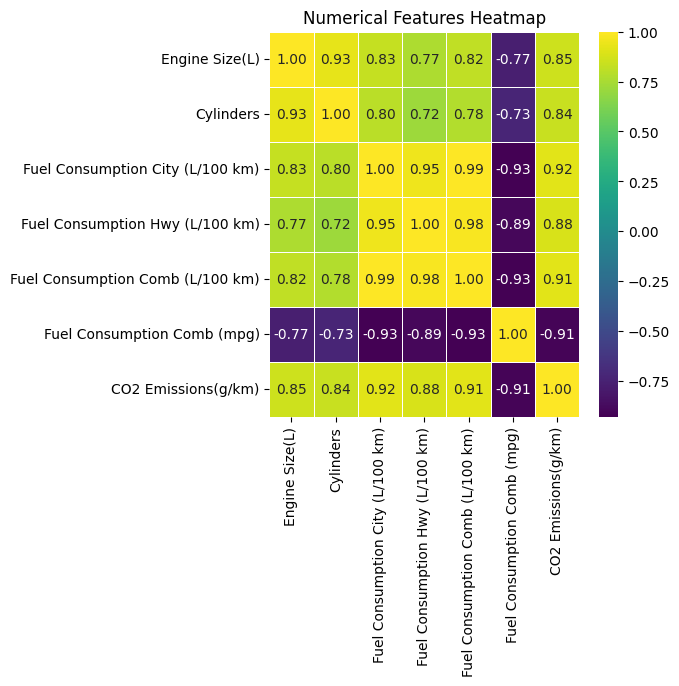

In [ ]:
numerical_cols = co2.select_dtypes(include=np.number).columns.tolist()
# numerical_cols.remove('CO2 Emissions(g/km)')
# numerical_cols.remove('Fuel Consumption Comb (L/100 km)')
co2[numerical_cols]
plt.figure(figsize=(5, 5))
sns.heatmap(co2[numerical_cols].corr(), annot=True,cmap='viridis', fmt=".2f", linewidths=.5)
plt.title("Numerical Features Heatmap")
plt.show()



All numerical columns are strongly correlated positively or negatively.
Fuel Consumption City (L/100 km), Fuel Consumption Comb (L/100 km), Fuel Consumption Comb (mpg) have strongest influences on CO2 emissions(g/km)

#Q4
Create visual summaries that reveal how emission levels change with respect to
different numerical variables in the dataset. Focus on uncovering patterns or
trends that might not be immediately visible

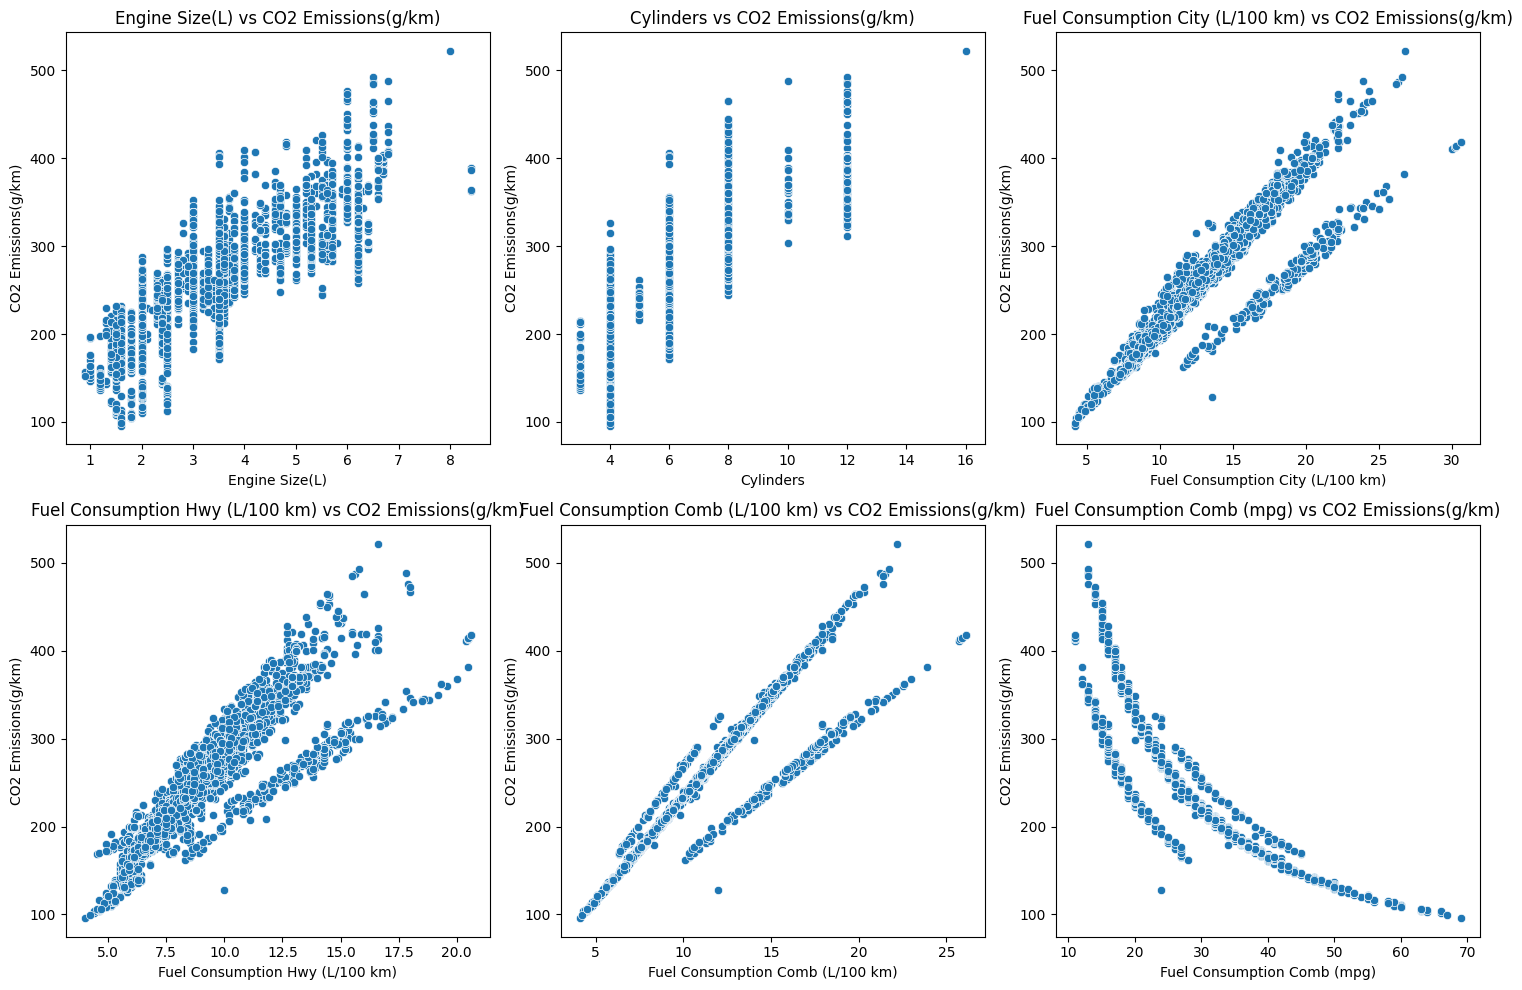

In [ ]:
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the axes array for easy iteration

# Loop through the numerical features and create a scatter plot against CO2 Emissions
for i, col in enumerate(numerical_features):
    sns.scatterplot(data=co2, x=col, y='CO2 Emissions(g/km)', ax=axes[i])
    axes[i].set_title(f'{col} vs CO2 Emissions(g/km)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('CO2 Emissions(g/km)')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

For features:


1. Engine Size(L): It is showing a approximate linear association- indicating that this is a key indicator of CO2 missions. Minor variations in vertical scatter may result from other features
2. Number of Cylinders: For even valued data it clearly shows a linear association, but odd values make it an approximate linear association with upward trend
3. For Fuel Consumption City (L/100 km), Fuel Consumption Hwy (L/100 km), and Fuel Consumption Comb (L/100 km), we can clearly see a linear association with upward trend
4. For Fuel Consumption Comb (mpg) has a clear non-linear association with a downward trend



# Q5
Compare emission levels across different vehicle types or fuel categories.
Identify any clear distinctions or surprising findings that emerge

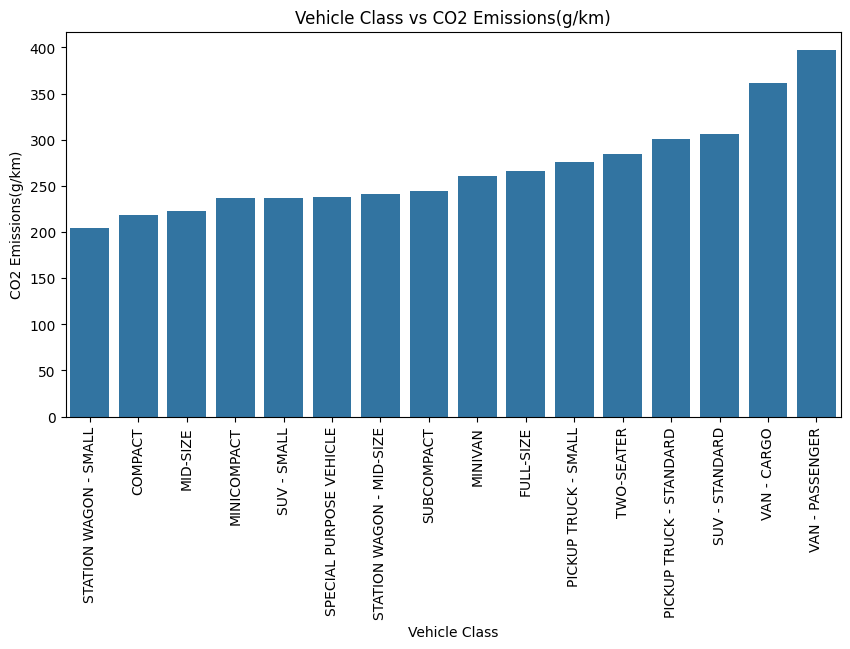

In [ ]:
co2_group_VC=co2.groupby(['Vehicle Class'])['CO2 Emissions(g/km)'].mean().sort_values()
co2_group_VC
plt.figure(figsize=(10,5))
sns.barplot(x=co2_group_VC.index, y=co2_group_VC.values)
plt.title('Vehicle Class vs CO2 Emissions(g/km)')
plt.xlabel('Vehicle Class')
plt.xticks(rotation=90)
plt.ylabel('CO2 Emissions(g/km)')
plt.show()

In [ ]:
# replacing fuel type data to original values
co2['Fuel Type']=co2['Fuel Type'].replace({'X':'Regular gasoline', 'Z':'Premium gasoline', 'D':'Diesel', 'E':'Ethanol (E85)', 'N':'Natural gas'})

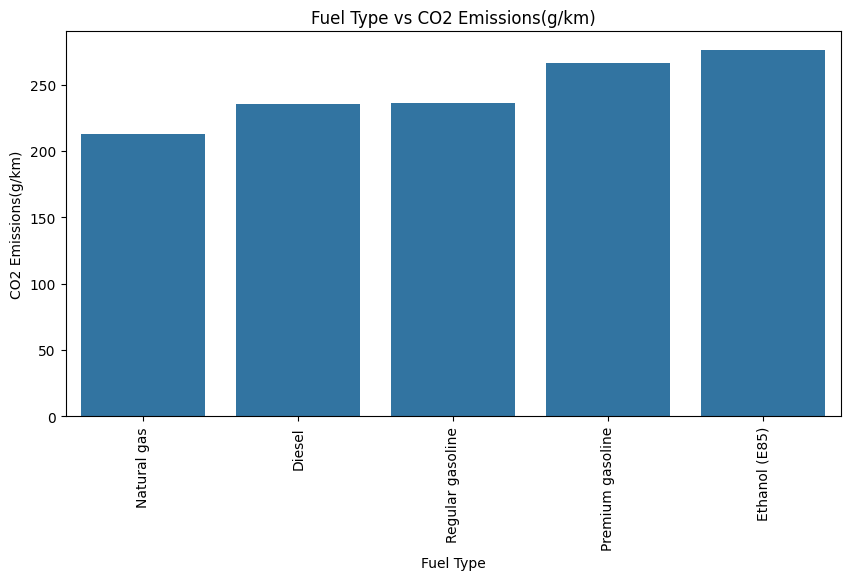

In [ ]:
co2_group_fuel=co2.groupby(['Fuel Type'])['CO2 Emissions(g/km)'].mean().sort_values()
plt.figure(figsize=(10,5))
sns.barplot(x=co2_group_fuel.index, y=co2_group_fuel.values)
plt.title('Fuel Type vs CO2 Emissions(g/km)')
plt.xlabel('Fuel Type')
plt.xticks(rotation=90)
plt.ylabel('CO2 Emissions(g/km)')
plt.show()

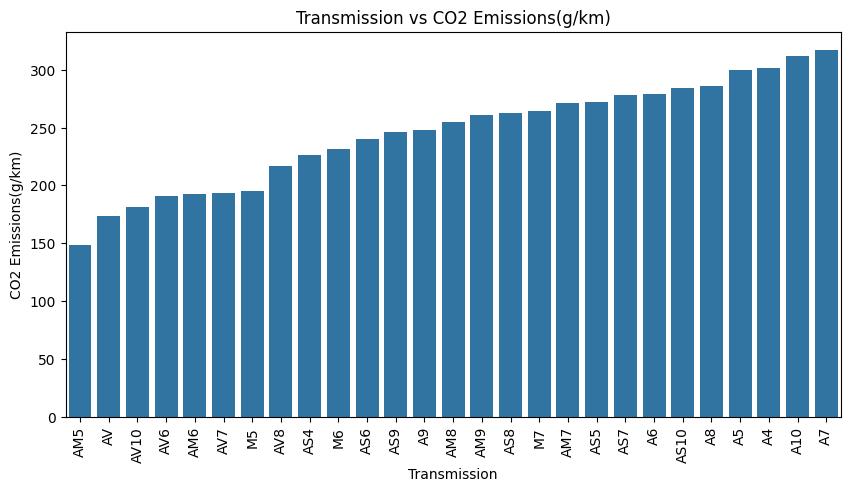

In [ ]:
co2_group_trans=co2.groupby(['Transmission'])['CO2 Emissions(g/km)'].mean().sort_values()
plt.figure(figsize=(10,5))
sns.barplot(x=co2_group_trans.index, y=co2_group_trans.values)
plt.title('Transmission vs CO2 Emissions(g/km)')
plt.xlabel('Transmission')
plt.xticks(rotation=90)
plt.ylabel('CO2 Emissions(g/km)')
plt.show()

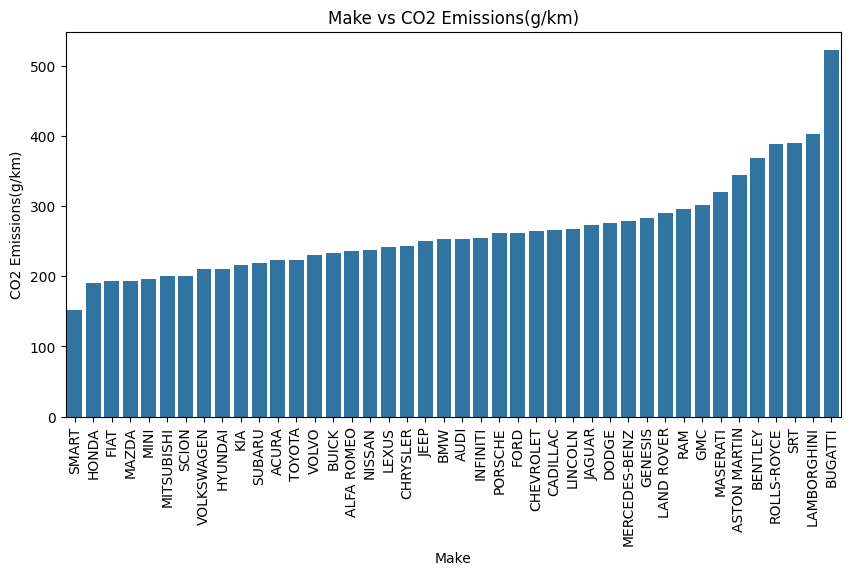

In [ ]:
co2_group_make=co2.groupby(['Make'])['CO2 Emissions(g/km)'].mean().sort_values()
plt.figure(figsize=(10,5))
sns.barplot(x=co2_group_make.index, y=co2_group_make.values)
plt.title('Make vs CO2 Emissions(g/km)')
plt.xlabel('Make')
plt.xticks(rotation=90)
plt.ylabel('CO2 Emissions(g/km)')
plt.show()

Emission Level relation with categorical columns:


1. Vehicle Class: Station Wagon small has lowest mean emissions, whereas VAN Passengers has highest mean emissions
2. Fuel Type: Natural Gas has lowest mean emissions, Ethanol(85) has highest mean emissions. Diesel and Regualr Gasoline are observed to have similar mean emissions.
3. Transmission: AM5(Automatic manual 5 gears) has lowest mean emissions, whereas A7, A10 (Automatic 7,10 gears) has highest emissions
4. Make: Vehicle models made by SMART have least mean emissions whereas BUGATTI models have highest mean emissions



# Q6
Observe if there are any vehicles that produce unusually high or low emissions
compared to others with similar characteristics. Reflect on what could explain
such deviations

In [ ]:
# parsing transmission into trans_type and gears
co2[['transtype', 'gears']] = co2['Transmission'].str.extract(r'(.*?)(?P<numbers>\d+)?$', expand=True) #extract trailing numbers(optional) and leading text
co2['gears'] = co2['gears'].fillna(0).astype(int)

In [ ]:
# binning by engine size
np.sort(co2['Engine Size(L)'].unique())


array([0.9, 1. , 1.2, 1.3, 1.4, 1.5, 1.6, 1.8, 2. , 2.1, 2.2, 2.3, 2.4,
       2.5, 2.7, 2.8, 2.9, 3. , 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 4. ,
       4.2, 4.3, 4.4, 4.6, 4.7, 4.8, 5. , 5.2, 5.3, 5.4, 5.5, 5.6, 5.7,
       5.8, 5.9, 6. , 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 8. , 8.4])

Engine Size values range from 0 to 9, so grouping bins 0-2, 2-4, so on

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
co2['enginesize_bins'] = pd.cut(co2['Engine Size(L)'], bins=[0, 4, 6, 10], right=False, labels=['2L', '5L' , '8L'])
# Since above 8 litres there are only 7 rows, reduced the number of bins
co2.groupby('enginesize_bins').size()

,0
enginesize_bins,
2L,4565
5L,1094
8L,332


In [ ]:
# Categorize fuel types into 'Gasoline' and 'Non-Gasoline'
gasoline_types = ['Regular gasoline', 'Premium gasoline']
co2['fuel_type_group'] = co2['Fuel Type'].apply(lambda x: 'Gasoline' if x in gasoline_types else 'Non-Gasoline')
carwag_types = ['COMPACT', 'MINICOMPACT', 'SUBCOMPACT', 'MID-SIZE', 'FULL-SIZE', 'TWO-SEATER', 'STATION WAGON - SMALL', 'STATION WAGON - MID-SIZE']
co2['body_buckets'] = co2['Vehicle Class'].apply(lambda x: 'CarWagon' if x in carwag_types else 'TruckVanSUV')


In [ ]:
co2['cluster'] = co2['body_buckets'].astype(str) + 'X' + co2['fuel_type_group'].astype(str)
co2.groupby('cluster').size()

,0
cluster,
CarWagonXGasoline,3523
CarWagonXNon-Gasoline,126
TruckVanSUVXGasoline,1996
TruckVanSUVXNon-Gasoline,346


In [ ]:
q1 = co2.groupby('cluster')['CO2 Emissions(g/km)'].transform(lambda s: s.quantile(0.25))
q3 = co2.groupby('cluster')['CO2 Emissions(g/km)'].transform(lambda s: s.quantile(0.75))
iqr = q3-q1
med = co2.groupby('cluster')['CO2 Emissions(g/km)'].transform('median')
n = co2.groupby("cluster")['CO2 Emissions(g/km)'].transform("count")

co2["cluster_q1"] = q1
co2["cluster_q3"] = q3
co2["cluster_iqr"] = iqr
co2["cluster_median"] = med
co2["cluster_n"] = n

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

co2['is_lower_outlier'] = co2['CO2 Emissions(g/km)'] < lower_fence
co2['is_upper_outlier'] = co2['CO2 Emissions(g/km)'] > upper_fence
co2['is_outlier'] = co2['is_lower_outlier'] | co2['is_upper_outlier']

co2['abs_delta_from_median'] = (co2['CO2 Emissions(g/km)'] - co2['cluster_median']).abs()

top_outliers = co2[co2['is_outlier']].sort_values(['cluster', 'abs_delta_from_median'], ascending=[True, False]).groupby('cluster').head(5).loc[:, ["Make","Model","cluster","enginesize_bins","transtype","gears","Cylinders", 'CO2 Emissions(g/km)', "cluster_median","abs_delta_from_median", 'cluster_n',"is_lower_outlier","is_upper_outlier"]]

In [ ]:
top_outliers
# len(top_outliers)

,Make,Model,cluster,enginesize_bins,transtype,gears,Cylinders,CO2 Emissions(g/km),cluster_median,abs_delta_from_median,cluster_n,is_lower_outlier,is_upper_outlier
4509,BUGATTI,CHIRON,CarWagonXGasoline,8L,AM,7,16,522,228.0,294.0,3523,False,True
6046,LAMBORGHINI,AVENTADOR ROADSTER,CarWagonXGasoline,8L,AM,7,12,493,228.0,265.0,3523,False,True
6045,LAMBORGHINI,AVENTADOR COUPE,CarWagonXGasoline,8L,AM,7,12,487,228.0,259.0,3523,False,True
7058,LAMBORGHINI,AVENTADOR COUPE,CarWagonXGasoline,8L,AM,7,12,485,228.0,257.0,3523,False,True
5511,BENTLEY,MULSANNE,CarWagonXGasoline,8L,AS,8,8,465,228.0,237.0,3523,False,True
349,FORD,E350 WAGON,TruckVanSUVXGasoline,8L,A,5,10,488,268.0,220.0,1996,False,True
2971,MERCEDES-BENZ,AMG G 65,TruckVanSUVXGasoline,8L,AS,7,12,476,268.0,208.0,1996,False,True
5126,MERCEDES-BENZ,AMG G 65,TruckVanSUVXGasoline,8L,A,7,12,473,268.0,205.0,1996,False,True
4049,MERCEDES-BENZ,AMG G 65,TruckVanSUVXGasoline,8L,AS,7,12,467,268.0,199.0,1996,False,True
2434,CHEVROLET,EXPRESS 3500 PASSENGER,TruckVanSUVXGasoline,8L,A,6,8,465,268.0,197.0,1996,False,True


Data is clustered into 4 buckets: CarWagonXGasoline, CarWagonXNon-Gasoline, TruckVanSUVXGasoline, TruckVanSUVXNon-Gasoline
Within each cluster, outliers flagged using using IQR with median of CO2 Emissions(g/km).
Other features like enginesize_bins, transmission type, gears, cylinders are used for within-cluster explanation

Above table presents summaries high emissions in their respective categories:
1. CarWagonXnon-Gasoline: No vehicles with significant high or low emissions
2. CarWagonXGasoline: 7 geared Automated Manual transmission type with 12 cylinders and above 8Litres engine size is causing high emissions.
##### Eg: LAMBORGHINI	AVENTADOR ROADSTER
3. TruckVanSUVXGasoline: 12 cylindered Vehicles with above 8 Litre engine size and either Automatic with select shift or Automatic transmission type are causing high emissions
##### Eg: MERCEDES-BENZ	AMG G 65
4. TruckVanSUVXNon-Gasoline: 8 cylindered - 8 Litre engine vehicles with automatic transmission are causing high emissions.
##### Eg: CHEVROLET	EXPRESS 3500 PASSENGER FFV, GMC	SAVANA 3500 PASSENGER FFV
Additionally in this category, a 2-Litered engine with 7-geared--4-cylindered vehicle model: MERCEDES-BENZ has high emissions

Overall, Vehicles with more than 8-Liter engines -- {A, AM,AS} Transmission type -- more than 6-gears and {8, 10, 12, 16} cylindered vehicles are having high emissions in similar clusters

# Q7

Prepare the dataset for model building by ensuring that numerical and
categorical features are appropriately represented. Consider any transformations
or encodings that may improve interpretability

Steps:
1. Finalize columns for modelling
2. convert required categoricals to one-hot encodings
3. Train-Test split data

In [ ]:
# Fuel Consumption Comb (L/100 km) column correlation check
co2['Fuel Consumption Comb (L/100 km) calc'] = np.round(co2['Fuel Consumption City (L/100 km)']*0.55 + co2['Fuel Consumption Hwy (L/100 km)']*0.45, decimals=1)
co2[~(np.isclose(co2['Fuel Consumption Comb (L/100 km)'], co2['Fuel Consumption Comb (L/100 km) calc'], rtol=0.1, atol=0.1))]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),...,cluster_q1,cluster_q3,cluster_iqr,cluster_median,cluster_n,is_lower_outlier,is_upper_outlier,is_outlier,abs_delta_from_median,Fuel Consumption Comb (L/100 km) calc


In [ ]:
co2['Fuel Consumption Comb (mpg) calc'] = np.round(282.481436405132/co2['Fuel Consumption Comb (L/100 km)'], decimals=0)
co2[~(np.isclose(co2['Fuel Consumption Comb (mpg)'], co2['Fuel Consumption Comb (mpg) calc'], rtol=0.1, atol=0.1))]
# co2[['Fuel Consumption Comb (mpg)', 'Fuel Consumption Comb (mpg) calc']]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),...,cluster_q3,cluster_iqr,cluster_median,cluster_n,is_lower_outlier,is_upper_outlier,is_outlier,abs_delta_from_median,Fuel Consumption Comb (L/100 km) calc,Fuel Consumption Comb (mpg) calc


Since Fuel Consumption Comb (L/100 km) can be derived from Fuel Consumption City (L/100 km) and Fuel Consumption Hwy (L/100 km), so deleting it.
Similarly, Fuel Consumption Comb (L/100 km) and Fuel Consumption Comb (mpg) are both correlated, deleting Fuel Consumption Comb (mpg).

In [ ]:
co2.drop(columns=['Fuel Consumption Comb (L/100 km) calc', 'Fuel Consumption Comb (mpg) calc', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)'], inplace=True)
co2.drop(columns='Transmission', inplace=True)
co2.drop(columns = ['body_buckets', 'fuel_type_group', 'enginesize_bins', 'cluster_q1', 'cluster_q3', 'cluster_median', 'cluster_n', 'cluster_iqr','cluster','is_lower_outlier', 'is_upper_outlier', 'is_outlier', 'abs_delta_from_median'], inplace=True)

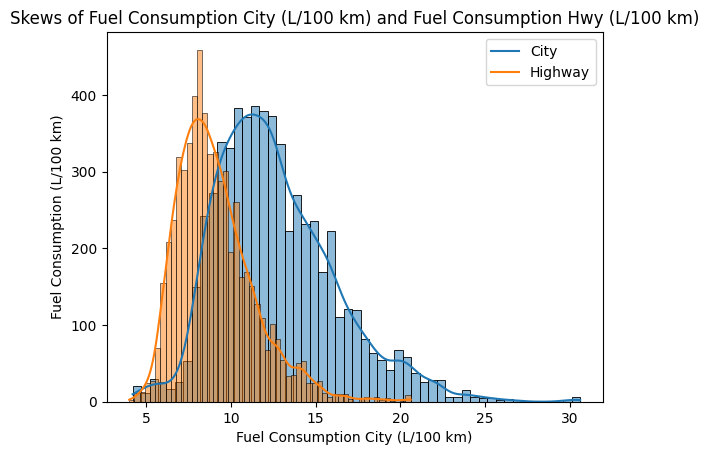

In [ ]:
# checking for and adjusting if right skewed
co2['Fuel Consumption City (L/100 km)'].skew() # 0.8 mean> median
co2['Fuel Consumption Hwy (L/100 km)'].skew() # 1.11 heavily skewed on the right
import seaborn as sns
sns.histplot(data=co2, x='Fuel Consumption City (L/100 km)', kde=True)
sns.histplot(data=co2, x='Fuel Consumption Hwy (L/100 km)', kde=True)
# plt.show()
co2['Fuel Consumption City (L/100 km) log'] = np.log(co2['Fuel Consumption City (L/100 km)'])
# sns.histplot(data=co2, x='Fuel Consumption City (L/100 km) log', kde=True)
co2['Fuel Consumption Hwy (L/100 km) log'] = np.log(co2['Fuel Consumption Hwy (L/100 km)'])
# sns.histplot(data=co2, x='Fuel Consumption Hwy (L/100 km) log', kde=True)
plt.title("Skews of Fuel Consumption City (L/100 km) and Fuel Consumption Hwy (L/100 km)")
plt.ylabel('Fuel Consumption (L/100 km)')
plt.legend(['City', 'Highway'])
plt.show()

Since Fuel Consumption City (L/100 km) and Fuel Consumption Hwy (L/100 km) are both right skewed, but not above 2, so using them directly without change.

In [ ]:
# co2.info()
#  One hot encoding columns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

cat = ["Fuel Type","Vehicle Class","transtype"]
num = ["Engine Size(L)","Cylinders","gears","Fuel Consumption City (L/100 km)", "Fuel Consumption Hwy (L/100 km)"]
target_var = co2['CO2 Emissions(g/km)']
features = co2[cat+num]

pre = ColumnTransformer([
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), cat),
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler())  # optional for linear/regularized models
    ]), num)
])

Categoricals ["Fuel Type","Vehicle Class","transtype"] are converted to one-hots with dropped first column.
Make and Model are considered as identifiers only, not used in modelling.

# Q8
Develop a simple, interpretable model to estimate CO₂ emissions using relevant
features from the dataset. Summarize how the model captures the relationship
between vehicle characteristics and emissions

In [ ]:
# Making Test - Train split 20-80
model = Pipeline([
    ("prep", pre),
    ("est", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(features, target_var, test_size=0.2)#, random_state=42) # reproducibile

model.fit(X_train, y_train)

test_score = model.score(X_test, y_test)
train_score = model.score(X_train, y_train)
print(train_score, test_score)

0.9914101990252757 0.9892957461498416


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Q9
Assess how well the model performs in estimating emissions. Reflect on the
meaning of the performance metrics and what they indicate about model
reliability.

In [ ]:
# metrics
from sklearn.metrics import mean_squared_error, r2_score
# train data
std_train = y_train.std(ddof=1) # 58.96
y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)

print("Train Data Metrics")
print('--------------')
print("Mean Squared Error:", mse)
print("Root Mean Squared Error(RMSE):", rmse)
print("nRMSE:", rmse/std_train)
print("R-squared:", r2)
# test data
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test Data Metrics")
print('--------------')
print("Mean Squared Error:", mse)
print("Root Mean Squared Error(RMSE):", rmse)
print("nRMSE:", rmse/std_train)
print("R-squared:", r2)

Train Data Metrics
--------------
Mean Squared Error: 30.271964359265958
Root Mean Squared Error(RMSE): 5.501996397605687
nRMSE: 0.09267150827145038
R-squared: 0.9914101990252757
Test Data Metrics
--------------
Mean Squared Error: 36.94209096653148
Root Mean Squared Error(RMSE): 6.07800057309404
nRMSE: 0.10237329137992132
R-squared: 0.9892957461498416


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


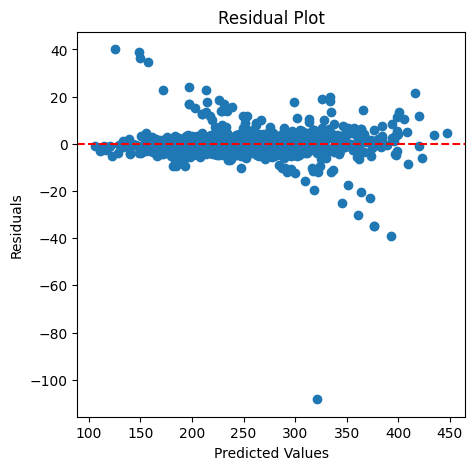

In [ ]:
from matplotlib import pyplot as plt
residuals = y_test - y_pred
plt.figure(figsize=(5, 5)) # Set figure size here
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


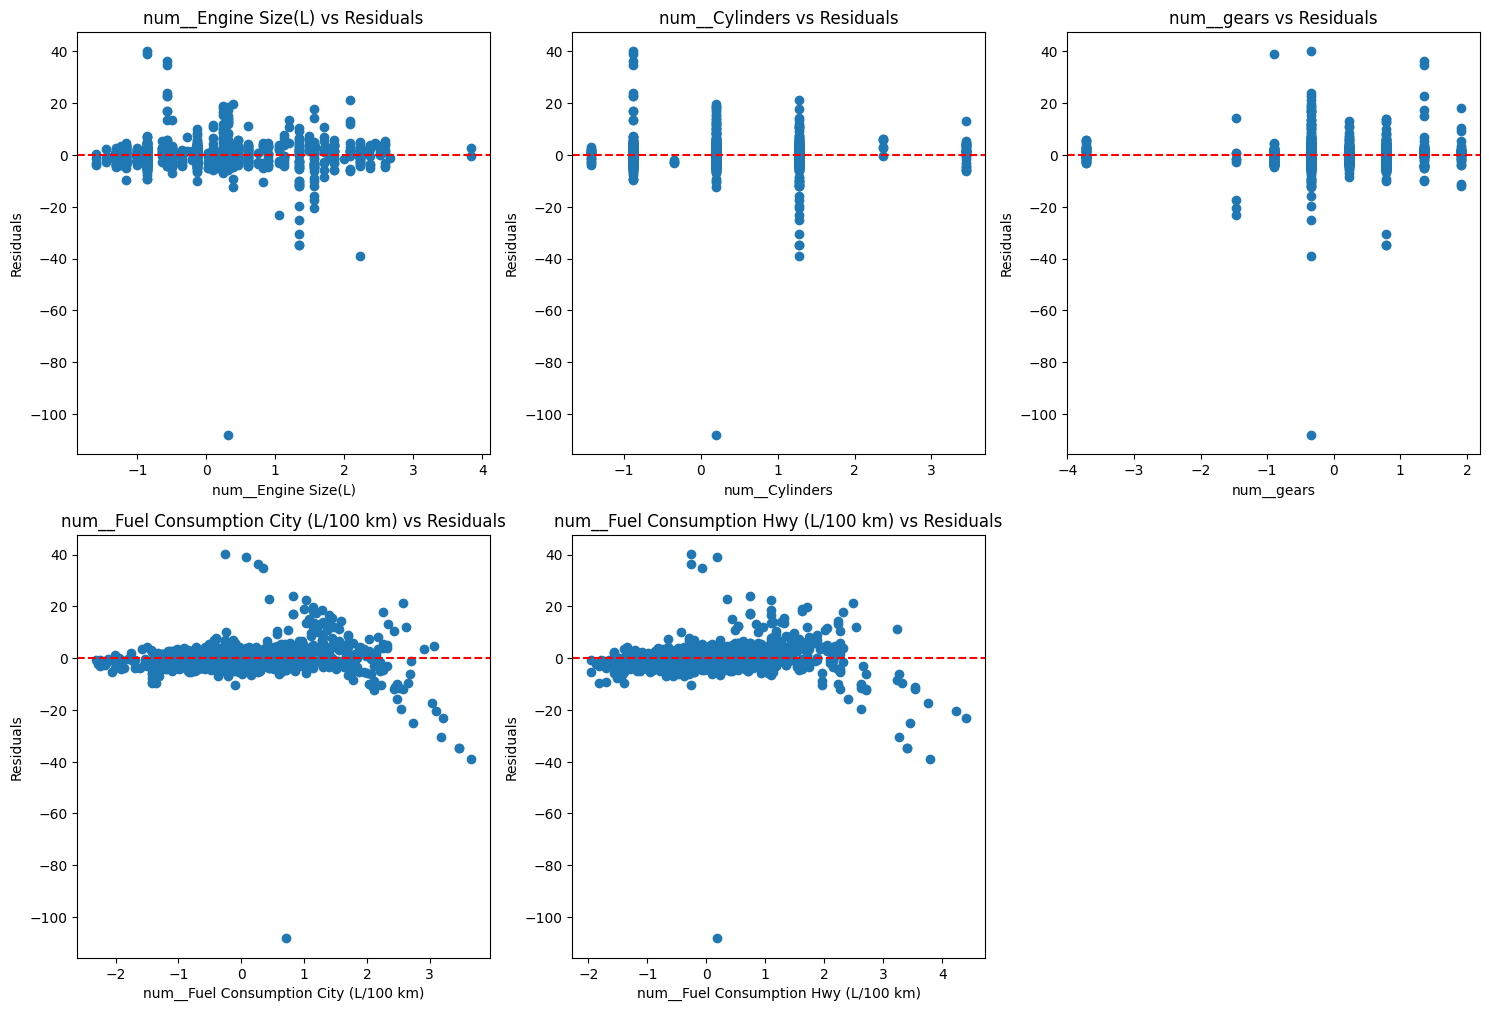

In [ ]:
# residual plots for numericals
feature_names = model.named_steps['prep'].get_feature_names_out()

n_cols = 3
n_rows = (len(feature_names) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the axes array for easy iteration

# Get the transformed features and convert to a dense array
X_test_transformed = model.named_steps['prep'].transform(X_test).toarray()
X_test_transformed_df = pd.DataFrame(X_test_transformed, index=X_test.index, columns=feature_names)
y_pred = model.named_steps['est'].predict(X_test_transformed)
residuals = y_test - y_pred

for i, col_name in enumerate(feature_names[-5:]):
    axes[i].scatter(X_test_transformed_df[col_name], residuals)
    axes[i].axhline(y=0, color='r', linestyle='--')
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(f'{col_name} vs Residuals')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. The model explain 98% of the variance in CO2 emissions on both train and test data.
2. Prediction errors near to 6 gm/km (RMSE) for both test and train data, indicating strong generalization and no overfitting.
3. Average error is near to 9% (from nRMSE) of the target's natural spread. So, no obvious overfitting.
4. Residual plots scatter randomly around zero for features without curve shape, fan or wedge
5. According to above residual vs numerical features, there appears to be no defined pattern. So, Residual variance is stable.
6. Discrete predictors like Cylinders and gears, do not show sgement-specific bias.
7. At extremely high Fuel Consumption Hwy (L/100 km) and Fuel Consumption City (L/100 km), residuals skew slightly negative. But the sample is very small.

# Q10
 Based on the analysis and model findings, summarize which factors most
strongly influence CO₂ emissions and suggest how such insights could support
emission reduction efforts

In [ ]:
# Preliminary analysis using coeffs
model.named_steps['est'].coef_#[-5:]
model.named_steps['prep'].get_feature_names_out()
coeff = pd.DataFrame(model.named_steps['est'].coef_, index=model.named_steps['prep'].get_feature_names_out(), columns=['Coefficient'])
coeff.sort_values(by='Coefficient', ascending=False, inplace=True)
coeff.head(10)

,Coefficient
num__Fuel Consumption City (L/100 km),44.990585
num__Fuel Consumption Hwy (L/100 km),21.610005
cat__Vehicle Class_SPECIAL PURPOSE VEHICLE,5.079854
cat__Vehicle Class_PICKUP TRUCK - SMALL,4.466168
cat__Vehicle Class_PICKUP TRUCK - STANDARD,2.611848
cat__Vehicle Class_SUV - SMALL,1.531296
cat__Vehicle Class_MINIVAN,1.419467
cat__Vehicle Class_FULL-SIZE,1.356130
cat__Vehicle Class_SUV - STANDARD,1.343904
cat__transtype_AM,1.190264


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

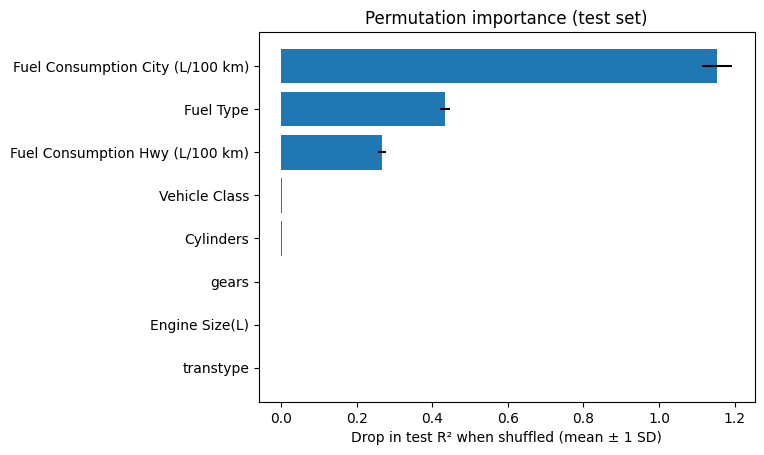

,feature,drop_in_R2,std,pct_drop_of_baseline_R2
6,Fuel Consumption City (L/100 km),1.153670,0.040128,116.615263
0,Fuel Type,0.433843,0.012681,43.853680
7,Fuel Consumption Hwy (L/100 km),0.266693,0.009333,26.957833
1,Vehicle Class,0.001146,0.000151,0.115879
4,Cylinders,0.000737,0.000117,0.074522
5,gears,0.000384,0.000068,0.038778
3,Engine Size(L),0.000031,0.000025,0.003183
2,transtype,-0.000007,0.000031,-0.000722


In [ ]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance using the original features
perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=0)

names = X_test.columns

# Create the DataFrame using original feature names and permutation importance results
imp_df = pd.DataFrame({
    "feature": names,
    "drop_in_R2": perm.importances_mean,      # mean decrease in R² when shuffled
    "std": perm.importances_std
}).sort_values("drop_in_R2", ascending=False)

imp_df["pct_drop_of_baseline_R2"] = 100 * imp_df["drop_in_R2"] / r2
import matplotlib.pyplot as plt

topk = 15
top = imp_df.head(topk).iloc[::-1]  # reverse for horizontal bar order
plt.barh(top["feature"], top["drop_in_R2"], xerr=top["std"])
plt.xlabel("Drop in test R² when shuffled (mean ± 1 SD)")
plt.title("Permutation importance (test set)")
plt.show()
imp_df

1. This horizontal bar graph and table tells us the importance of each feature using permutation importance method
2. Fuel Consumption City (L/100 km): Shuffling this has a drop of 115% in R2 (pct_drop_of_baseline_R2). This means that this is highly important feature in CO2 emissions
3. Similarly. Fuel Type and Fuel Consumption Hwy (L/100 km) are also important features in this model.
4. All other features have marginal additional predictive power.
5. Model falls more than 100% for Fuel Consumption City (L/100 km), meaning model heavily relies on this feature.
6. Fuel Consumption Hwy (L/100 km) is also important individually, but less than Fuel Consumption City (L/100 km)

Problem statement:
The Global Automotive Council aims to understand the key factors influencing vehicle
CO₂ emissions and explore data-driven strategies for emission reduction.
A dataset containing detailed information on vehicle specifications, engine
characteristics, fuel types, and emission levels has been provided.
The objective is to analyze this dataset to uncover hidden patterns, identify the major
contributors to CO₂ emissions, and develop predictive models to support policy and
design decisions in the automotive sector.

Not required

In [ ]:
# # residuals for categories
# fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
# axes = axes.flatten() # Flatten the axes array for easy iteration

# for i, col_name in enumerate(feature_names[:-5]):
#     sns.boxplot(data=X_test_transformed_df, x=col_name, y='Residuals', ax=axes[i])
#     axes[i].axhline(y=0, color='r', linestyle='--')
#     axes[i].set_xlabel(col_name)
#     axes[i].set_ylabel('Residuals')
#     axes[i].set_title(f'{col_name} vs Residuals')
# # Hide any unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

P-Value

In [ ]:
prep = model.named_steps['prep']
Xtr = prep.transform(X_train)
ytr = y_train

import statsmodels.api as sm
feature_names = prep.get_feature_names_out()

# Sanitize feature names to be compatible with statsmodels
sanitized_feature_names = [name.replace('[', '_').replace(']', '_').replace('<', '_').replace('>', '_').replace('=', '_').replace(' ', '_').replace('-', '_').replace('(', '_').replace(')', '_') for name in feature_names]

# Use the NumPy array directly and add a constant
Xtr_sm = sm.add_constant(Xtr.toarray(), prepend=True) # Add constant to the NumPy array

# Note: statsmodels might still have issues with column names if provided as a DataFrame
# Using the NumPy array directly with feature names for reference
ols = sm.OLS(ytr, Xtr_sm).fit(cov_type="HC3")
summ = ols.summary(xname=['const'] + sanitized_feature_names) # Provide sanitized feature names for summary
summ

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     CO2 Emissions(g/km)   R-squared:                       0.991
Model:                             OLS   Adj. R-squared:                  0.991
Method:                  Least Squares   F-statistic:                 2.760e+04
Date:                 Sun, 14 Dec 2025   Prob (F-statistic):               0.00
Time:                         07:24:28   Log-Likelihood:                -14970.
No. Observations:                 4792   AIC:                         3.000e+04
Df Residuals:                     4764   BIC:                         3.018e+04
Df Model:                           27                                         
Covariance Type:                   HC3                                         
===============================================================================================================
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                         284.7521      0.740    384.700      0.000     283.301     286.203
cat__Fuel_Type_Ethanol__E85_                 -141.3949      1.547    -91.427      0.000    -144.426    -138.364
cat__Fuel_Type_Premium_gasoline               -29.0140      0.668    -43.434      0.000     -30.323     -27.705
cat__Fuel_Type_Regular_gasoline               -28.7335      0.638    -45.016      0.000     -29.985     -27.483
cat__Vehicle_Class_FULL_SIZE                    1.3562      0.350      3.875      0.000       0.670       2.042
cat__Vehicle_Class_MID_SIZE                    -0.0365      0.276     -0.132      0.895      -0.578       0.505
cat__Vehicle_Class_MINICOMPACT                 -0.2196      0.286     -0.768      0.442      -0.780       0.341
cat__Vehicle_Class_MINIVAN                      1.4187      0.577      2.460      0.014       0.288       2.549
cat__Vehicle_Class_PICKUP_TRUCK___SMALL         4.4663      0.568      7.857      0.000       3.352       5.580
cat__Vehicle_Class_PICKUP_TRUCK___STANDARD      2.6119      0.545      4.789      0.000       1.543       3.681
cat__Vehicle_Class_SPECIAL_PURPOSE_VEHICLE      5.0819      1.252      4.060      0.000       2.629       7.535
cat__Vehicle_Class_STATION_WAGON___MID_SIZE     0.6031      0.461      1.308      0.191      -0.301       1.507
cat__Vehicle_Class_STATION_WAGON___SMALL       -0.3287      0.285     -1.154      0.249      -0.887       0.230
cat__Vehicle_Class_SUBCOMPACT                   0.1076      0.245      0.440      0.660      -0.372       0.587
cat__Vehicle_Class_SUV___SMALL                  1.5314      0.316      4.843      0.000       0.912       2.151
cat__Vehicle_Class_SUV___STANDARD               1.3439      0.406      3.312      0.001       0.549       2.139
cat__Vehicle_Class_TWO_SEATER                   0.6836      0.294      2.326      0.020       0.108       1.260
cat__Vehicle_Class_VAN___CARGO                -10.6591      4.259     -2.503      0.012     -19.006      -2.312
cat__Vehicle_Class_VAN___PASSENGER            -10.3568      3.087     -3.355      0.001     -16.408      -4.306
cat__transtype_AM                               1.1902      0.359      3.319      0.001       0.487       1.893
cat__transtype_AS                               0.3693      0.237      1.560      0.119      -0.095       0.833
cat__transtype_AV                              -0.0399      0.385     -0.104      0.918      -0.795       0.715
cat__transtype_M                                0.1989      0.258      0.772      0.440      -0.306       0.704
num__Engine_Size_L_                             0.2186      0.212      1.031      0.302      -0.197       0.634
num__Cylinders                                  